# BRFSS income → health gradients: does the measurement model matter?

**Read-only overview.** This notebook summarizes the project and displays the key
results for two outcomes. The pipeline runs in sequence:

1. [`01_download.ipynb`](01_download.ipynb) — cache BRFSS 2023 + codebook; verify every coding.
2. [`02_recode.ipynb`](02_recode.ipynb) — build the analysis sample; map the two missingness mechanisms.
3. [`03_model_ABC.ipynb`](03_model_ABC.ipynb) — the A → B → C gradient comparison (frequent mental distress).
4. [`04_missingness_sensitivity.ipynb`](04_missingness_sensitivity.ipynb) — the refusal-MNAR sweep (FMD).
5. [`05_vision_difficulty.ipynb`](05_vision_difficulty.ipynb) — the same investigation for difficulty seeing.

See [`METHODS.md`](METHODS.md) for exact variables, bracket boundaries, codes, and references.

## The question

BRFSS household income (`INCOME3`) is **interval-censored** (11 brackets, an open top
bracket at \$200k+) with **two distinct kinds of missing** that the published files
collapse into one: **Refused (99)** and **Don't know (77)**. Standard practice assigns
bracket midpoints and listwise-deletes the missing. We ask how much the estimated
income–health gradient — the OR per **doubling of income** — moves as we replace those
shortcuts:

- **A** — bracket midpoints + listwise deletion (standard practice).
- **B** — grouped-data lognormal likelihood (honors brackets + open top tail), missing dropped.
- **C** — adds the missing: don't-know as MAR, refused as MNAR with a sensitivity sweep.

Two outcomes: **frequent mental distress** (`MENTHLTH` ≥ 14 days) and **serious
difficulty seeing, even with glasses** (`BLIND`). All inference is design-based
(weights `_LLCPWT`, strata `_STSTR`).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = os.path.abspath(os.path.join('..', 'data'))
DERIVED = os.path.join(DATA, 'derived')

def load(tag):
    t = pd.read_csv(os.path.join(DERIVED, f'brfss_income_ABC_table{tag}.csv'))
    s = pd.read_csv(os.path.join(DERIVED, f'brfss_income_mnar_sweep{tag}.csv'))
    return t, s

fmd_tab, fmd_sweep = load('')
vis_tab, vis_sweep = load('_vision')
print('Frequent mental distress:'); print(fmd_tab.to_string(index=False))
print('\nDifficulty seeing:'); print(vis_tab.to_string(index=False))

Frequent mental distress:
                      model  OR per doubling  95% CI low  95% CI high  log-OR/doubling  lin SE  n used
     A. midpoint + listwise           0.8526      0.8333       0.8723          -0.1595  0.0117  338056
      B. grouped + listwise           0.8364      0.8162       0.8572          -0.1786  0.0125  338056
C. grouped + two-mech (γ=0)           0.8369      0.8166       0.8576          -0.1781  0.0125  408944

Difficulty seeing:
                      model  OR per doubling  95% CI low  95% CI high  log-OR/doubling  lin SE  n used
     A. midpoint + listwise           0.7553      0.7268       0.7848          -0.2807  0.0196  338342
      B. grouped + listwise           0.7277      0.6966       0.7601          -0.3179  0.0223  338342
C. grouped + two-mech (γ=0)           0.7273      0.6961       0.7599          -0.3184  0.0223  409359


## The A → B → C gradient, both outcomes

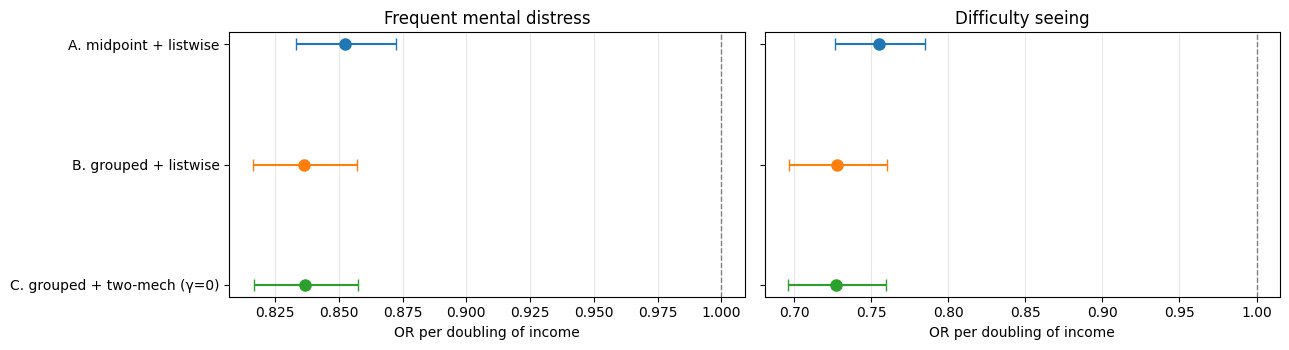

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), sharey=True)
for ax, tab, title in [(axes[0], fmd_tab, 'Frequent mental distress'),
                       (axes[1], vis_tab, 'Difficulty seeing')]:
    ys = [2, 1, 0]
    for y, (_, r) in zip(ys, tab.iterrows()):
        ax.errorbar([r['OR per doubling']], [y],
                    xerr=[[r['OR per doubling'] - r['95% CI low']],
                          [r['95% CI high'] - r['OR per doubling']]],
                    fmt='o', capsize=4, ms=8)
    ax.axvline(1.0, color='gray', ls='--', lw=1)
    ax.set_yticks(ys); ax.set_yticklabels(tab['model'])
    ax.set_xlabel('OR per doubling of income'); ax.set_title(title); ax.grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

## Refusal-MNAR sensitivity, both outcomes

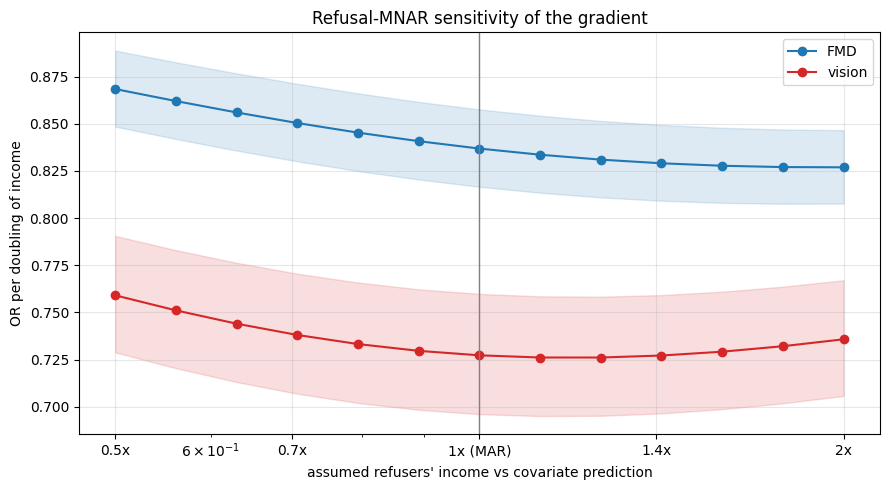

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
for s, tab, lab, c in [(fmd_sweep, fmd_tab, 'FMD', 'C0'),
                       (vis_sweep, vis_tab, 'vision', 'C3')]:
    ax.fill_between(s['income_ratio'], s['or_lo'], s['or_hi'], alpha=0.15, color=c)
    ax.plot(s['income_ratio'], s['or'], '-o', color=c, label=lab)
ax.axvline(1.0, color='gray', lw=1)
ax.set_xscale('log'); ax.set_xticks([0.5, 0.7, 1.0, 1.4, 2.0])
ax.set_xticklabels(['0.5x', '0.7x', '1x (MAR)', '1.4x', '2x'])
ax.set_xlabel("assumed refusers' income vs covariate prediction")
ax.set_ylabel('OR per doubling of income')
ax.set_title('Refusal-MNAR sensitivity of the gradient'); ax.legend()
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## What we found

In [4]:
def summarize(name, tab, sweep):
    A, B, C = tab.iloc[0], tab.iloc[1], tab.iloc[2]
    ab = 100 * (B['OR per doubling'] - A['OR per doubling']) / A['OR per doubling']
    bc = 100 * (C['OR per doubling'] - B['OR per doubling']) / B['OR per doubling']
    print(f'{name}:')
    print(f"  A {A['OR per doubling']:.3f} [{A['95% CI low']:.3f},{A['95% CI high']:.3f}]  "
          f"B {B['OR per doubling']:.3f} [{B['95% CI low']:.3f},{B['95% CI high']:.3f}]  "
          f"C {C['OR per doubling']:.3f} [{C['95% CI low']:.3f},{C['95% CI high']:.3f}]")
    print(f"  A->B {ab:+.1f}%   B->C {bc:+.1f}%   "
          f"MNAR sweep OR {sweep['or'].min():.3f}-{sweep['or'].max():.3f}")
summarize('Frequent mental distress', fmd_tab, fmd_sweep)
summarize('Difficulty seeing', vis_tab, vis_sweep)
print('\nThe plain-language interpretation is written out in METHODS.md.')

Frequent mental distress:
  A 0.853 [0.833,0.872]  B 0.836 [0.816,0.857]  C 0.837 [0.817,0.858]
  A->B -1.9%   B->C +0.1%   MNAR sweep OR 0.827-0.868
Difficulty seeing:
  A 0.755 [0.727,0.785]  B 0.728 [0.697,0.760]  C 0.727 [0.696,0.760]
  A->B -3.7%   B->C -0.1%   MNAR sweep OR 0.726-0.759

The plain-language interpretation is written out in METHODS.md.
